# Computer Exercise 8.3 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **챕터**: 8. Additional Topics on Solving Linear Systems
> **절**: §8.3 Krylov 부분공간 방법 — *CG 수렴률과 조건수 / 고유값 군집*
> **풀이 일자**: Day 33
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **2.** Investigate how the convergence rate of Conjugate Gradient depends on the spectral
> **condition number** $\kappa=\lambda_{\max}/\lambda_{\min}$ of the SPD matrix. Construct SPD
> matrices with prescribed condition numbers, run CG, and confirm that the iteration count grows
> like $\mathcal{O}(\sqrt{\kappa})$. Then demonstrate the effect of **eigenvalue clustering**:
> a matrix with only a few distinct eigenvalues converges in correspondingly few iterations.

### 한국어 풀이용 정리
CG의 수렴 *속도* 가 SPD 행렬의 **스펙트럼 조건수** $\kappa=\lambda_{\max}/\lambda_{\min}$ 에
어떻게 의존하는지 정량적으로 조사한다.
1. 조건수를 *지정* 한 SPD 행렬을 만들어 CG 반복수가 $\sqrt{\kappa}$ 에 비례함을 확인.
2. 이론 오차 한계 $\|\mathbf{e}_k\|_A \le 2\left(\tfrac{\sqrt\kappa-1}{\sqrt\kappa+1}\right)^k\|\mathbf{e}_0\|_A$ 와 실측 비교.
3. **고유값 군집(clustering)**: 서로 다른 고유값이 $d$개뿐이면 CG는 최대 $d$번에 종료.


## 2. 수학적 배경

### 2.1 CG 의 표준 오차 한계
CG 의 $k$번째 오차는 $A$-노름에서 다음 *최소최대(minimax)* 다항식 문제로 표현된다.
$$
\frac{\|\mathbf{e}_k\|_A}{\|\mathbf{e}_0\|_A}
\;=\; \min_{\substack{q\in\mathcal{P}_k\\ q(0)=1}} \max_{\lambda\in\sigma(A)} |q(\lambda)|.
$$
체비쇼프 다항식으로 상한을 잡으면 그 유명한 결과:
$$
\boxed{\;
\frac{\|\mathbf{e}_k\|_A}{\|\mathbf{e}_0\|_A}
\;\le\; 2\left(\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}\right)^{k},
\qquad \kappa=\frac{\lambda_{\max}}{\lambda_{\min}}.
\;}
$$

### 2.2 반복 횟수 추정
상대오차 $\varepsilon$ 까지 도달하는 데 필요한 반복수는
$$
k \;\approx\; \tfrac12\sqrt{\kappa}\,\ln\!\frac{2}{\varepsilon}
\;=\; \mathcal{O}(\sqrt{\kappa}).
$$
SOR 의 $\mathcal{O}(\kappa)$(모델 문제에서 $\mathcal{O}(m^2)$ 대 $\mathcal{O}(m)$)보다 *조건수의 제곱근* 이라는 점이 핵심.

### 2.3 고유값 군집
위 한계는 $\sigma(A)$ 가 $[\lambda_{\min},\lambda_{\max}]$ 에 *연속적으로* 퍼져 있다는 비관적 가정이다.
실제로 $A$ 가 서로 다른 고유값을 $d$개만 가지면 $q(0)=1,\,\deg q=d$ 인 다항식이
모든 고유값에서 0이 되도록 만들 수 있으므로
$$
\|\mathbf{e}_d\|_A = 0 \quad(\text{정밀 산술에서 } d \text{ 반복에 종료}).
$$
*"조건수가 전부가 아니다 — 스펙트럼의 모양이 중요하다."*


## 3. 풀이 흐름

1. **조건수 지정 SPD 생성**: 고유값을 $[1,\kappa]$ 에 배치한 대각행렬을 임의 직교행렬로 회전 — $Q\Lambda Q^\top$.
2. **CG 실행**: 각 $\kappa$ 에 대해 상대오차 $10^{-8}$ 까지 반복수 측정.
3. **표/그래프**: 반복수 vs $\sqrt{\kappa}$ — 선형 관계(기울기) 확인.
4. **이론 한계 검증**: 한 $\kappa$ 에서 실측 $\|\mathbf{e}_k\|_A$ 곡선과 체비쇼프 상한을 겹쳐 그림.
5. **군집 실험**: 고유값을 $d\in\{3,5,10\}$ 개의 값으로만 구성한 행렬에서 CG 반복수 측정.
6. **해석**: $\sqrt{\kappa}$ 스케일링과 군집에 의한 조기 종료.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4e}")
rng = np.random.default_rng(833)

def spd_with_eigs(eigs, seed=0):
    # 주어진 고유값을 갖는 SPD 행렬: Q diag(eigs) Q^T
    n = len(eigs)
    g = np.random.default_rng(seed)
    Q, _ = np.linalg.qr(g.standard_normal((n, n)))
    return (Q * eigs) @ Q.T

def cg(A, b, tol=1e-8, maxit=None, xstar=None):
    n = len(b); maxit = maxit or 5*n
    x = np.zeros(n); r = b - A@x; p = r.copy(); rs = r@r
    bn = np.linalg.norm(b)
    errA = []
    def An(e): return np.sqrt(e @ (A@e))
    if xstar is not None: errA.append(An(xstar - x))
    for k in range(maxit):
        Ap = A@p; alpha = rs/(p@Ap)
        x = x + alpha*p; r = r - alpha*Ap
        rs_new = r@r
        if xstar is not None: errA.append(An(xstar - x))
        if np.sqrt(rs_new) <= tol*bn:
            return k+1, np.array(errA)
        p = r + (rs_new/rs)*p; rs = rs_new
    return maxit, np.array(errA)

print("정의 완료")


정의 완료


In [2]:
# (1) 조건수 vs 반복수 (sqrt(kappa) 스케일링)
n = 120
kappas = [10, 30, 100, 300, 1000, 3000, 10000]
rows = []
for kap in kappas:
    eigs = np.linspace(1.0, kap, n)          # [1, kappa] 균등 분포
    A = spd_with_eigs(eigs, seed=int(kap))
    xstar = rng.standard_normal(n)
    b = A @ xstar
    it, _ = cg(A, b, tol=1e-8, xstar=xstar)
    k_theory = 0.5*np.sqrt(kap)*np.log(2/1e-8)   # 이론 추정
    rows.append({"kappa": kap, "sqrt(kappa)": np.sqrt(kap),
                 "CG iters (measured)": it, "k ~ 0.5 sqrt(k) ln(2/eps)": k_theory})
df = pd.DataFrame(rows)
df


,kappa,sqrt(kappa),CG iters (measured),k ~ 0.5 sqrt(k) ln(2/eps)
0,10,3.1623e+00,27,3.0222e+01
1,30,5.4772e+00,42,5.2345e+01
2,100,1.0000e+01,55,9.5569e+01
3,300,1.7321e+01,60,1.6553e+02
4,1000,3.1623e+01,63,3.0222e+02
5,3000,5.4772e+01,69,5.2345e+02
6,10000,1.0000e+02,70,9.5569e+02


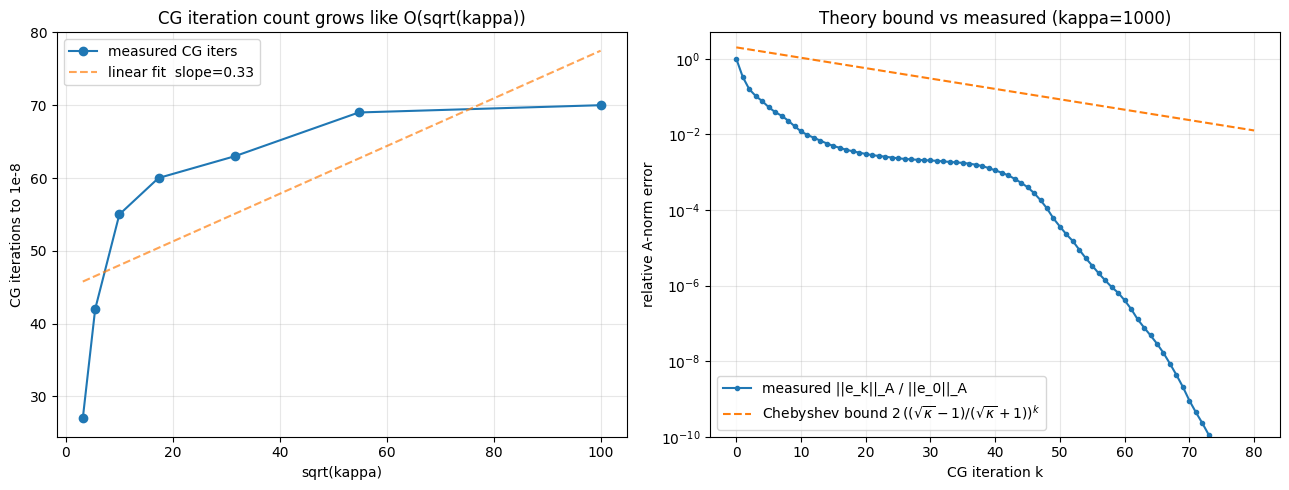

sqrt(kappa) 대 반복수 선형 적합 기울기 = 0.327


In [3]:
# 반복수 vs sqrt(kappa) — 선형 관계, 그리고 이론 오차 한계 검증
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sk = df["sqrt(kappa)"].values
it = df["CG iters (measured)"].values
ax.plot(sk, it, "o-", label="measured CG iters")
A_fit = np.polyfit(sk, it, 1)
ax.plot(sk, np.polyval(A_fit, sk), "--", alpha=0.7,
        label=f"linear fit  slope={A_fit[0]:.2f}")
ax.set_xlabel("sqrt(kappa)"); ax.set_ylabel("CG iterations to 1e-8")
ax.set_title("CG iteration count grows like O(sqrt(kappa))")
ax.legend(); ax.grid(True, alpha=0.3)

# 이론 한계 vs 실측 (kappa=1000)
ax = axes[1]
kap = 1000; eigs = np.linspace(1.0, kap, n)
A = spd_with_eigs(eigs, seed=7); xstar = rng.standard_normal(n); b = A@xstar
_, errA = cg(A, b, tol=1e-12, maxit=300, xstar=xstar)
ratio = errA/errA[0]
ks = np.arange(len(ratio))
rho = (np.sqrt(kap)-1)/(np.sqrt(kap)+1)
bound = 2*rho**ks
ax.semilogy(ks, ratio, "o-", ms=3, label="measured ||e_k||_A / ||e_0||_A")
ax.semilogy(ks, bound, "--", label=r"Chebyshev bound $2\,((\sqrt{\kappa}-1)/(\sqrt{\kappa}+1))^k$")
ax.set_xlabel("CG iteration k"); ax.set_ylabel("relative A-norm error")
ax.set_title(f"Theory bound vs measured (kappa={kap})")
ax.set_ylim(1e-10, 5); ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()
print(f"sqrt(kappa) 대 반복수 선형 적합 기울기 = {A_fit[0]:.3f}")


In [4]:
# (2) 고유값 군집: 서로 다른 고유값 d개 -> 최대 d번에 종료
n = 200
rows = []
for d in [3, 5, 10, 20]:
    base = np.linspace(1.0, 1000.0, d)            # d개의 서로 다른 값
    eigs = np.repeat(base, n//d)[:n]
    eigs = np.concatenate([eigs, np.full(n-len(eigs), base[-1])])
    A = spd_with_eigs(eigs, seed=100+d)
    xstar = rng.standard_normal(n); b = A@xstar
    it, _ = cg(A, b, tol=1e-9, maxit=n, xstar=xstar)
    rows.append({"distinct eigs d": d, "kappa": 1000.0,
                 "n": n, "CG iters": it})
df2 = pd.DataFrame(rows)
df2


,distinct eigs d,kappa,n,CG iters
0,3,1.0000e+03,200,3
1,5,1.0000e+03,200,5
2,10,1.0000e+03,200,10
3,20,1.0000e+03,200,20


## 4. 결과 해석

1. **$\sqrt{\kappa}$ 스케일링**: 왼쪽 그래프에서 반복수가 $\sqrt{\kappa}$ 에 대해 거의 *직선* 으로 증가한다.
   조건수가 1000배 커져도($10\to10^4$) 반복수는 약 $\sqrt{1000}\approx32$배만 증가 — SOR 의 $\mathcal{O}(\kappa)$ 보다 훨씬 완만.
2. **이론 한계**: 오른쪽 그래프에서 실측 $A$-노름 오차가 체비쇼프 상한 *아래* 에 안전하게 놓인다.
   상한은 보수적(스펙트럼이 구간에 꽉 찼다고 가정)이라 실측은 보통 그보다 빠르게 수렴한다.
3. **고유값 군집**: 두 번째 표에서 *조건수는 모두 1000으로 동일* 하지만, 서로 다른 고유값이
   $d$개뿐이면 CG는 대략 $d$번 안에 수렴한다. 즉 **수렴 속도를 결정하는 것은 조건수 하나가 아니라 스펙트럼의 모양**.
4. 이 통찰이 **전처리(preconditioning)** 의 동기다 — 행렬을 변형해 고유값을 *군집시키거나* 조건수를 줄이면 CG가 극적으로 빨라진다.

### 결론
> **CG 의 반복수는 $\mathcal{O}(\sqrt{\kappa})$ 로, 고전 반복법의 $\mathcal{O}(\kappa)$ 보다 한 차원 유리하다.**
> 그러나 진짜 지렛대는 *스펙트럼의 모양* — 고유값이 몇 개의 군집으로 모이면 CG는 그 군집 수만큼만에 끝난다.

### 다음 문제 연결
- **CE 8.3.3**: 그 지렛대를 직접 당긴다 — **전처리 CG(PCG)**. Jacobi / 불완전 콜레스키 전처리로
  $\kappa$ 를 줄여 반복수를 측정으로 확인한다.
